In [29]:
import os
import time
from tqdm import tqdm

import numpy as np

import concurrent

from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.stats import sigma_clipped_stats, sigma_clip

import pyvo

import matplotlib.pyplot as plt



# maybe needed
#
#import multiprocess as mp
#import contextlib
#from photutils.aperture import CircularAperture, aperture_photometry


# Suppress logging temporarily to prevent astropy
# from repeatedly printing out warning notices related to alternate WCSs
import logging
logging.getLogger('astropy').setLevel(logging.ERROR)


In [22]:
## FUNCTIONS
# Will have to be put in separate file in the end for clean up

def tap_search(adql, maxrec=None, retries=3, delay=5, IRSA_TAP_URL="https://irsa.ipac.caltech.edu/TAP"):
    """Run a TAP query against ``tap_service`` with retry logic for transient errors.

    Parameters
    ----------
    adql : str
        ADQL query string.
    maxrec : int, optional
        Maximum number of rows to return (passed as TAP MAXREC).
    retries : int, optional
        Maximum number of attempts before re-raising the exception.
    delay : float, optional
        Seconds to wait between attempts.
    IRSA_TAP_URL: str
        Link to IRSA TAP. Default is "https://irsa.ipac.caltech.edu/TAP".

    Returns
    -------
    `~pyvo.dal.TAPResults`
        Query result object; call ``.to_table()`` to get an Astropy Table.

    Raises
    ------
    `~pyvo.dal.DALServiceError`
        If the server returns an error on the final attempt.
    """
    import time as _time
    from pyvo.dal import DALServiceError

    ## Set up TAP service
    tap_service = pyvo.dal.TAPService(IRSA_TAP_URL)
    
    for attempt in range(retries):
        try:
            return tap_service.search(adql, maxrec=maxrec)
        except DALServiceError as e:
            if attempt < retries - 1:
                print(f"TAP query failed ({e}); retrying in {delay}s… (attempt {attempt+1}/{retries})")
                _time.sleep(delay)
            else:
                raise


def process_cutout(row, ra, dec, size=None,
                   cache=False, uri_key="s3_uri", repo="S3"):

    """
    Retrieve a FITS image or cutout from a remote repository.
    
    This is a convenience wrapper that dispatches to the appropriate
    processing function depending on the requested repository.
    
    Parameters
    ----------
    row : dict-like
        A mutable table row (e.g., an ``astropy.table.Row``) that is updated
        in place with the downloaded HDUs and associated metadata.
    
    ra : float or `~astropy.units.Quantity`
        Right ascension (ICRS). If a scalar is provided, it is interpreted
        as decimal degrees. If a `~astropy.units.Quantity` is provided, it
        must have angular units.
    
    dec : float or `~astropy.units.Quantity`
        Declination (ICRS). If a scalar is provided, it is interpreted
        as decimal degrees. If a `~astropy.units.Quantity` is provided, it
        must have angular units.
    
    size : int, float, or `~astropy.units.Quantity`, optional
        Size of the requested cutout.
    
        - For ``repo="S3"``, a scalar is interpreted as pixels, while a
          `~astropy.units.Quantity` may be specified in pixels or angular
          units (e.g., ``11*u.pixel`` or ``30*u.arcsec``).
        - For ``repo="IRSA"``, the size represents the angular size of the
          requested cutout. A scalar is interpreted as decimal degrees,
          while a `~astropy.units.Quantity` must have angular units.
    
        The default is ``None`` (functions will choose if not user defined).
    
    cache : bool, optional
        Whether to cache the remote FITS file locally. Default is ``False``.
    
    uri_key : str, optional
        Name of the column in ``row`` containing the URI or base URI used
        to retrieve the FITS data. The interpretation depends on ``repo``.
    
    repo : {"S3", "IRSA"}, optional
        Repository from which to retrieve the FITS data. ``"S3"`` accesses
        cloud-hosted FITS files using Amazon S3, while ``"IRSA"`` retrieves
        cutouts from the IRSA archive. Default is ``"S3"``.
    
    Returns
    -------
    bool
        ``True`` if the retrieval and processing were successful,
        ``False`` otherwise.
    
    Raises
    ------
    ValueError
        If ``repo`` is not one of ``"S3"`` or ``"IRSA"``.
    
    Notes
    -----
    This function modifies ``row`` in place by adding the downloaded HDUs
    and associated spectral metadata.
    """

    
    if repo == "S3":
        return _process_cutout_s3(
            row=row, ra=ra, dec=dec,
            size=size, cache=cache, uri_key=uri_key
        )
    elif repo == "IRSA":
        return _process_cutout_irsa(
            row=row, ra=ra, dec=dec,
            size=size, cache=cache, uri_key=uri_key
        )
    else:
        raise ValueError("repo must be either 'S3' or 'IRSA'.")




def _process_cutout_s3(row, ra, dec, size=11*u.pixel, cache=False, uri_key="s3_uri"):
    """
    Download cutouts from a cloud-hosted FITS file and store them in a table row.

    The function opens a FITS file stored in an S3 bucket using
    ``astropy.io.fits`` with ``fsspec``, extracts a cutout centered on the
    specified sky coordinates for the ``IMAGE``, ``FLAGS``, and ``VARIANCE``
    extensions, and preserves the WCS in each cutout. It also computes the
    central wavelength and spectral bandwidth at the requested position using
    the spectral WCS.

    Parameters
    ----------
    row : dict-like
        A mutable table row (e.g., an ``astropy.table.Row``) that is updated
        in place. The following fields are added:

        - ``"hdus"`` : list of FITS HDUs containing the cutouts.
        - ``"central_wavelength"`` : Central wavelength in microns.
        - ``"bandwidth"`` : Spectral bandwidth in microns.

    ra : float or `~astropy.units.Quantity`
        Right ascension of the cutout center (ICRS). If a scalar is
        provided, it is interpreted as decimal degrees. If a
        `~astropy.units.Quantity` is provided, it must have angular units.

    dec : float or `~astropy.units.Quantity`
        Declination of the cutout center (ICRS). If a scalar is
        provided, it is interpreted as decimal degrees. If a
        `~astropy.units.Quantity` is provided, it must have angular units.

    size : int, float, or `~astropy.units.Quantity`, optional
        Size of the cutout. If a scalar is provided, it is interpreted
        as a size in pixels. Alternatively, an
        `~astropy.units.Quantity` may be supplied (e.g.,
        ``11*u.pixel`` or ``30*u.arcsec``). The default is
        ``11*u.pixel``.

    cache : bool, optional
        Whether to cache the remote FITS file locally. Passed to
        ``astropy.io.fits.open``. Default is ``False``.

    uri_key : str, optional
        Name of the column in ``row`` containing the S3 URI of the FITS file.
        Default is ``"s3_uri"``.

    Returns
    -------
    bool
        Returns ``True`` if the cutout and metadata were successfully
        generated.

    Raises
    ------
    TypeError
        If ``size`` is neither a scalar nor an
        `~astropy.units.Quantity`, or if ``ra`` or ``dec`` are neither
        scalars nor `~astropy.units.Quantity` objects.

    ValueError
        If ``ra`` or ``dec`` are given as
        `~astropy.units.Quantity` objects that do not have angular units.

    Notes
    -----
    This function modifies ``row`` in place. The FITS file is expected to
    contain ``IMAGE``, ``FLAGS``, and ``VARIANCE`` extensions, as well as a
    valid spectral WCS under the ``"W"`` coordinate key.
    """

    # Allow a scalar to be interpreted as pixels.
    if not isinstance(size, u.Quantity):
        if np.isscalar(size):
            size = size * u.pixel
        else:
            raise TypeError(
                "size must be either a scalar (interpreted as pixels) "
                "or an astropy.units.Quantity."
            )

    # Allow scalars to be interpreted as degrees.
    if not isinstance(ra, u.Quantity):
        if np.isscalar(ra):
            ra = ra * u.deg
        else:
            raise TypeError(
                "ra must be either a scalar (interpreted as degrees) "
                "or an astropy.units.Quantity."
            )
    elif not ra.unit.is_equivalent(u.deg):
        raise ValueError("ra must have angular units.")

    if not isinstance(dec, u.Quantity):
        if np.isscalar(dec):
            dec = dec * u.deg
        else:
            raise TypeError(
                "dec must be either a scalar (interpreted as degrees) "
                "or an astropy.units.Quantity."
            )
    elif not dec.unit.is_equivalent(u.deg):
        raise ValueError("dec must have angular units.")

    position = SkyCoord(ra=ra, dec=dec, frame="icrs")

    uri = row[uri_key]

    with fits.open(uri, fsspec_kwargs={"anon": True}, cache=cache) as hdul:

        keys = ["IMAGE", "FLAGS", "VARIANCE"]

        hdus = []
        for key in keys:
            cutout = Cutout2D(
                hdul[key].section,
                position=position,
                size=size,
                wcs=WCS(hdul[key].header),
                mode="partial"
            )

            hdu = fits.PrimaryHDU(data=cutout.data, header=hdul[key].header)
            hdu.header.update(cutout.wcs.to_header())
            hdus.append(hdu)

        row["hdus"] = hdus

        spatial_wcs = WCS(hdul["IMAGE"].header)
        x, y = spatial_wcs.world_to_pixel(position)

        spectral_wcs = WCS(hdul["IMAGE"].header, fobj=hdul, key="W")
        spectral_wcs.sip = None
        wavelength, bandpass = spectral_wcs.pixel_to_world(x, y)

        row["central_wavelength"] = wavelength.to(u.um).value
        row["bandwidth"] = bandpass.to(u.um).value

    return(True)


def _process_cutout_irsa(row, ra, dec, size=60*u.arcsec, cache=False, uri_key="irsa_uri"):
    """
    Download a FITS cutout from the IRSA archive and store it in a table row.

    The function opens a remote FITS file hosted by the IRSA archive,
    reads the ``IMAGE``, ``FLAGS``, and ``VARIANCE`` extensions, and stores
    them as FITS HDUs in the supplied table row. It also computes the
    central wavelength and spectral bandwidth at the specified sky
    coordinates using the spectral WCS.

    Parameters
    ----------
    row : dict-like
        A mutable table row (e.g., an ``astropy.table.Row``) that is updated
        in place. The following fields are added:

        - ``"hdus"`` : list of FITS HDUs containing the downloaded images.
        - ``"central_wavelength"`` : Central wavelength in microns.
        - ``"bandwidth"`` : Spectral bandwidth in microns.

    ra : float or `~astropy.units.Quantity`
        Right ascension (ICRS). If a scalar is provided, it is interpreted
        as decimal degrees. If a `~astropy.units.Quantity` is provided, it
        must have angular units.

    dec : float or `~astropy.units.Quantity`
        Declination (ICRS). If a scalar is provided, it is interpreted
        as decimal degrees. If a `~astropy.units.Quantity` is provided, it
        must have angular units.

    size : float or `~astropy.units.Quantity`, optional
        Angular size of the requested cutout. If a scalar is provided,
        it is interpreted as decimal degrees. If a
        `~astropy.units.Quantity` is provided, it must have angular
        units. The default is ``60*u.arcsec``.

    cache : bool, optional
        Whether to cache the remote FITS file locally. Passed to
        ``astropy.io.fits.open``. Default is ``False``.

    uri_key : str, optional
        Name of the column in ``row`` containing the base IRSA cutout URL.
        The requested position and cutout size are appended as query
        parameters. Default is ``"irsa_uri"``.

    Returns
    -------
    bool
        Returns ``True`` if the FITS file was successfully downloaded and
        processed, and ``False`` otherwise.

    Raises
    ------
    TypeError
        If ``ra``, ``dec``, or ``size`` are neither scalars nor
        `~astropy.units.Quantity` objects.
    
    ValueError
        If ``ra``, ``dec``, or ``size`` are given as
        `~astropy.units.Quantity` objects that do not have angular units.

    Notes
    -----
    This function modifies ``row`` in place. On success, the downloaded cutout HDUs
    and spectral metadata are stored in ``row``. If the FITS file
    cannot be opened or processed, the function returns ``False`` and
    leaves the row unchanged.
    """

    # Allow scalars to be interpreted as degrees.
    if not isinstance(size, u.Quantity):
        if np.isscalar(size):
            size = size * u.deg
        else:
            raise TypeError(
                "size must be either a scalar (interpreted as degrees) "
                "or an astropy.units.Quantity."
            )
    elif not size.unit.is_equivalent(u.deg):
        raise ValueError("size must have angular units.")
    
    # Allow scalars to be interpreted as degrees.
    if not isinstance(ra, u.Quantity):
        if np.isscalar(ra):
            ra = ra * u.deg
        else:
            raise TypeError(
                "ra must be either a scalar (interpreted as degrees) "
                "or an astropy.units.Quantity."
            )
    elif not ra.unit.is_equivalent(u.deg):
        raise ValueError("ra must have angular units.")

    if not isinstance(dec, u.Quantity):
        if np.isscalar(dec):
            dec = dec * u.deg
        else:
            raise TypeError(
                "dec must be either a scalar (interpreted as degrees) "
                "or an astropy.units.Quantity."
            )
    elif not dec.unit.is_equivalent(u.deg):
        raise ValueError("dec must have angular units.")


    position = SkyCoord(ra=ra, dec=dec, frame="icrs")

    # construct the URI
    # Note: from IRSA we can directly download the cutouts! 
    uri = row[uri_key]

    #uri = f"{uri}?center={ra.to(u.degree).value},{dec.to(u.degree).value}d&size={size.to(u.degree).value}"
    uri = (
        f"{uri}"
        f"?center={ra.to_value(u.deg)},{dec.to_value(u.deg)}d"
        f"&size={size.to_value(u.deg)}d"
    )

    # Note that some cutouts may not have an overlap. In this case
    # we just skip the row and leave the default values. We can filter
    # out later the images that couldn't be retrieved.
    try:
        with fits.open(uri, cache=cache) as hdul:
    
            keys = ["IMAGE", "FLAGS", "VARIANCE"]
    
            hdus = []
            for key in keys:
                hdu = fits.PrimaryHDU(data=hdul[key].data, header=hdul[key].header)
                hdus.append(hdu)
    
            row["hdus"] = hdus
    
            spatial_wcs = WCS(hdul["IMAGE"].header)
            x, y = spatial_wcs.world_to_pixel(position)
    
            spectral_wcs = WCS(hdul["IMAGE"].header, fobj=hdul, key="W")
            spectral_wcs.sip = None
            wavelength, bandpass = spectral_wcs.pixel_to_world(x, y)
    
            row["central_wavelength"] = wavelength.to(u.um).value
            row["bandwidth"] = bandpass.to(u.um).value

        return(True)
        
    except Exception as e:
        print(f"Failed to process {uri}: {e}")
        return(False)

    
def search_lvfs(ra, dec, IRSA_TAP_URL = "https://irsa.ipac.caltech.edu/TAP"):

    """
    Search the SPHEREx IRSA TAP service for Level-2 images covering a sky position.
    
    Parameters
    ----------
    ra : `~astropy.units.Quantity`
        Right ascension (ICRS) of the target position.
    
    dec : `~astropy.units.Quantity`
        Declination (ICRS) of the target position.
    
    IRSA_TAP_URL : str, optional
        URL of the IRSA TAP service. Default is the public IRSA TAP endpoint.
    
    Returns
    -------
    `~astropy.table.Table`
        Table of matching SPHEREx Level-2 images containing the columns
        ``energy_bandpassname``, ``time_bounds_lower``,
        ``time_bounds_upper``, and ``uri``.
    """

    ## Set up Search
    adql = f"""
    SELECT
        p.energy_bandpassname, p.time_bounds_lower, p.time_bounds_upper, a.uri
    FROM spherex.artifact a
    JOIN spherex.plane p ON a.planeid = p.planeid
    WHERE CONTAINS(POINT('ICRS', {ra.to(u.degree).value}, {dec.to(u.degree).value}), p.poly) = 1
    """
    
    ## Run Query
    print("Querying IRSA TAP for L2 images…")
    lvf_result = tap_search(adql, maxrec=5000, IRSA_TAP_URL=IRSA_TAP_URL)
    lvf_results = lvf_result.to_table()
    print(f"Found {len(lvf_results)} L2 images covering RA = {ra.to_value(u.degree)}, Dec = {dec.to_value(u.degree)}")
    if lvf_result.query_status == "OVERFLOW":
        print("WARNING: result count hit the MAXREC limit — some images may be missing. "
              "Raise the maxrec value in the tap_service.search() call if needed.")

    return(lvf_results)




In [23]:
## INPUT FOR TOOL ##

INPUT = dict()

INPUT["target_name"] = "2MASS 21282814-0559310"
INPUT["RA"] = 322.117265*u.degree
INPUT["DEC"] = -5.991964*u.degree
INPUT["tmpdir"] = "../tmp/"
INPUT["outdir"] = "../output/"
INPUT["cutout_size"] = 11*u.pixel


In [24]:
## SEARCH LVF IMAGES ===========
lvf_results = search_lvfs(ra = INPUT["RA"],
                         dec = INPUT["DEC"]
                         )

Querying IRSA TAP for L2 images…
Found 283 L2 images covering RA = 322.117265, Dec = -5.991964


In [25]:
## GET IRSA LINKS ========
irsa_base = "https://irsa.ipac.caltech.edu/"
lvf_results["irsa_uri"] = [os.path.join(irsa_base , t["uri"]) for t in lvf_results]

## GET S3 BUCKET LINKS ==========
bucket_name = "nasa-irsa-spherex"
s3_access = f"s3://{bucket_name}"
lvf_results["s3_access"] = [os.path.join(s3_access, "/".join(t["uri"].split("/")[3:])) for t in lvf_results]

In [35]:
## GET CUTOUTS FROM S3 (parallel) =============
# we choose the S3 cloud cutout tool. Alternatively
# once could choose the IRSA cutout tool (_process_cutout_irsa)
## Prepare
lvf_results["cutout_index"] = range(1, len(lvf_results) + 1)
lvf_results["central_wavelength"] = np.full(len(lvf_results), np.nan)
lvf_results["bandwidth"] = np.full(len(lvf_results), np.nan)
lvf_results["hdus"] = np.full(len(lvf_results), None)

## get Cutouts
t1 = time.time()
print("Starting to create cutouts...")
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    futures = [
        executor.submit(
            _process_cutout_s3,
            row=row,
            ra=INPUT["RA"],
            dec=INPUT["DEC"],
            size=INPUT["cutout_size"],
            cache=False,
            uri_key="s3_access",
        )
        for row in lvf_results[:30]
    ]
    concurrent.futures.wait(futures)
print("Done - time to create cutouts in parallel mode: {:2.2f} minutes.".format( (time.time()-t1)/60 ) )


Starting creating cutouts...
Done - time to create cutouts in parallel mode: 0.31 minutes.
CPU times: user 12.8 s, sys: 4.01 s, total: 16.9 s
Wall time: 18.4 s


In [ ]:
HERE

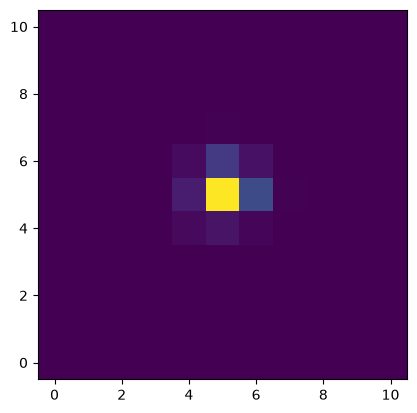

In [13]:
plt.imshow(lvf_results["hdus"][0][0].data, origin="lower")

In [ ]:
TEST

In [68]:
%%time
#s3_uri = "s3://stpubdata/hst/public/j8pu/j8pu0y010/j8pu0y010_drc.fits"
s3_uri = "s3://nasa-irsa-spherex/qr2/level2/2025W19_1B/l2b-v20-2025-242/1/level2_2025W19_1B_0186_1D1_spx_l2b-v20-2025-242.fits"
# Download a small 10-by-20 pixel cutout from a FITS file stored in Amazon S3
with fits.open(s3_uri, fsspec_kwargs={"anon": True}, cache=False) as hdul:
    cutout = hdul[1].section[10:20, 30:50]

CPU times: user 168 ms, sys: 99.3 ms, total: 267 ms
Wall time: 617 ms
